In [ ]:
#Install Required Dependencies
import subprocess
subprocess.run([
    "pip", "install",
    "keras~=3.8.0",
    "matplotlib~=3.10.0",
    "numpy~=2.0.0",
    "pandas~=2.2.0",
    "tensorflow~=2.18.0",
    "kaleido==0.2.1",
    "seaborn~=0.13.0",
])

CompletedProcess(args=['pip', 'install', 'google-ml-edu==0.1.3', 'keras~=3.8.0', 'matplotlib~=3.10.0', 'numpy~=2.0.0', 'pandas~=2.2.0', 'tensorflow~=2.18.0', 'kaleido==0.2.1', 'seaborn~=0.13.0'], returncode=0)

In [ ]:
#Load dependencies

#Data
import numpy as np
import pandas as pd

#Machine Learning
import keras

#Data Visualization 
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


from dataclasses import dataclass, field

In [43]:
#Hyperparameters for the model
@dataclass
class ModelSettings:
    learning_rate: float
    number_epochs: int
    batch_size: int
    input_features: list[str] = field(default_factory=list)

In [32]:
#Load & Prepare the Data
chicago_taxi_dataset = pd.read_csv(
  "https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv"  
)

training_df = chicago_taxi_dataset[
    ["TRIP_MILES", "TRIP_SECONDS", "FARE", "COMPANY", "PAYMENT_TYPE", "TIP_RATE"]
].copy()

print(f"Rows loaded: {len(training_df)}")
print(training_df.describe(include='all'))

Rows loaded: 31694
          TRIP_MILES  TRIP_SECONDS          FARE    COMPANY PAYMENT_TYPE  \
count   31694.000000  31694.000000  31694.000000      31694        31694   
unique           NaN           NaN           NaN         31            7   
top              NaN           NaN           NaN  Flash Cab  Credit Card   
freq             NaN           NaN           NaN       7887        14142   
mean        8.289463   1319.796397     23.905210        NaN          NaN   
std         7.265672    928.932873     16.970022        NaN          NaN   
min         0.500000     60.000000      3.250000        NaN          NaN   
25%         1.720000    548.000000      9.000000        NaN          NaN   
50%         5.920000   1081.000000     18.750000        NaN          NaN   
75%        14.500000   1888.000000     38.750000        NaN          NaN   
max        68.120000   7140.000000    159.250000        NaN          NaN   

            TIP_RATE  
count   31694.000000  
unique           NaN  

In [45]:
#Exploratory Plots
def plot_scatter_matrix(df: pd.DataFrame, columns: list[str]) -> None:
    sns.pairplot(df[columns])
    plt.suptitle("Pairwise Relationships", y=1.02)
    plt.savefig("PairwiseRelationships.png", bbox_inches="tight")
    plt.show()

def plot_correlation_matrix(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        df.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm"
    )
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.savefig("CorrelationMatrix.png")
    plt.show()

In [46]:
#Model Creation
from tensorflow import shape


def create_model(
    settings: ModelSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
    """
    Builds and complies a single-layer linear model.
    One input node per feature -> Concatenate -> Dense(1) output
    """
    inputs = {
        name: keras.Input(shape=(1,), name=name)
        for name in settings.input_features
    }

    if len(inputs) == 1:
        # Concatenate requires ≥2 tensors; skip it for single-feature models.
        x = list(inputs.values())[0]
    else:
        x = keras.layers.Concatenate()(list(inputs.values()))    
  
    
    outputs = keras.layers.Dense(units=1, name="prediction")(x)
    model = keras.Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
        loss=keras.losses.MeanSquaredError(),
        metrics=metrics,
    )
    return model

In [ ]:
#Training the Model
def train_model(
        model_name: str,
        model: keras.Model,
        dataset: pd.DataFrame,
        label_name: str,
        settings: ModelSettings,
) -> dict:
    """
    Trains the model and returns a plain dictionary with everything needed for evaluation and plotting
    """
    features = {
        name: dataset[name].to_numpy()
        for name in settings.input_features
    }
    labels = dataset[label_name].to_numpy()

    history = model.fit(
        x=features,
        y=labels,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs,
        verbose=1,
    )

    return{
        "name": model_name,
        "model": model,
        "settings": settings,
        "history": pd.DataFrame(history.history),
        "epochs": history.epoch,
    }

In [48]:
#Results Plot
def plot_training_metrics(training: dict, metric_names: list[str]) -> None:
    """Line chart for one or more training metrics over epochs."""
    history = training["history"]

    fig, ax = plt.subplots(figsize=(8, 5))
    for metric in metric_names:
        if metric in history.columns:
            ax.plot(training["epochs"], history[metric], marker="o", label=metric)

    ax.set_title(f"Training Metrics — {training['name']}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Metric Value")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("TrainingMetrics.png")
    plt.show()


def plot_predictions(
    training: dict,
    dataset: pd.DataFrame,
    label_name: str,
    sample_size: int = 200,
) -> None:
    sample = dataset.sample(n=min(sample_size, len(dataset)), random_state=42).copy()
    features = {
        name: sample[name].to_numpy()
        for name in training["settings"].input_features
    }
    predictions = training["model"].predict(features, verbose=0).flatten()
    sample["_predicted"] = predictions

    if len(training["settings"].input_features) == 2:
        x_feat, y_feat = training["settings"].input_features

        # Build grid and predict surface
        x_range = np.linspace(sample[x_feat].min(), sample[x_feat].max(), 50)
        y_range = np.linspace(sample[y_feat].min(), sample[y_feat].max(), 50)
        xx, yy = np.meshgrid(x_range, y_range)
        zz = training["model"].predict(
            {x_feat: xx.ravel(), y_feat: yy.ravel()}, verbose=0
        ).reshape(xx.shape)

        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection="3d")

        # Prediction surface
        ax.plot_surface(xx, yy, zz, cmap="plasma", alpha=0.6, edgecolor="none")

        # Actual data points
        ax.scatter(
            sample[x_feat],
            sample[y_feat],
            sample[label_name],
            color="steelblue",
            s=20,
            alpha=0.6,
            label="Actual",
        )

        ax.set_title(f"Prediction Surface vs Actual — {training['name']}")
        ax.set_xlabel(x_feat)
        ax.set_ylabel(y_feat)
        ax.set_zlabel(label_name)
        ax.legend()

    else:
        # 2D fallback for single feature
        fig, ax = plt.subplots(figsize=(7, 6))
        ax.scatter(sample[label_name], predictions, alpha=0.5, label="Predictions")

        min_val = min(sample[label_name].min(), predictions.min())
        max_val = max(sample[label_name].max(), predictions.max())
        ax.plot([min_val, max_val], [min_val, max_val],
                color="red", linestyle="--", label="Perfect fit")

        ax.set_title(f"Predicted vs Actual — {training['name']}")
        ax.set_xlabel(f"Actual {label_name}")
        ax.set_ylabel(f"Predicted {label_name}")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig("PredictionPlot.png")
    plt.show()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ TRIP_MILES (InputLayer)         │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - loss: 1910.3008 - rmse: 43.6957
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - loss: 1342.2614 - rmse: 36.6211
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - loss: 847.7859 - rmse: 29.1054
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - loss: 487.8789 - rmse: 22.0640
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 227.3400 - rmse: 15.0506
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 70.5148 - rmse: 8.3501
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - loss: 14.5683 - rmse: 3.8133
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - loss: 15.0878 - rmse: 3.8804
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - loss: 13.2236 - rmse: 3.6302
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 14.1616 - rmse: 3.7599
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - loss: 14.8843 - rmse: 3.8513
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 767us/s

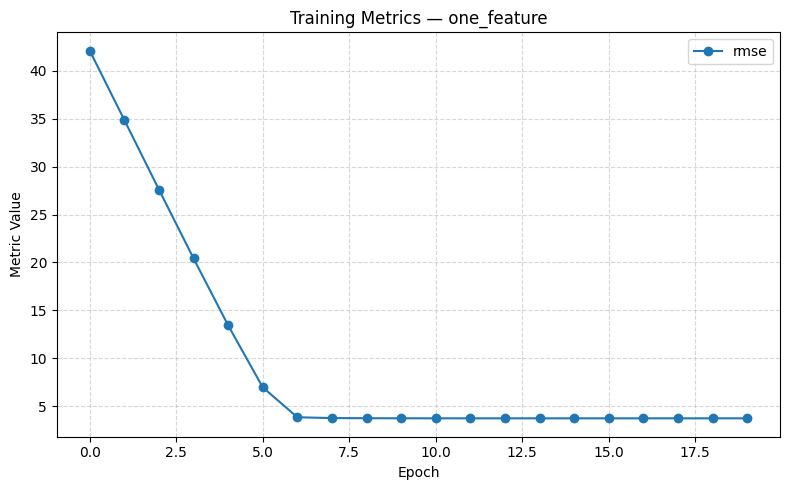

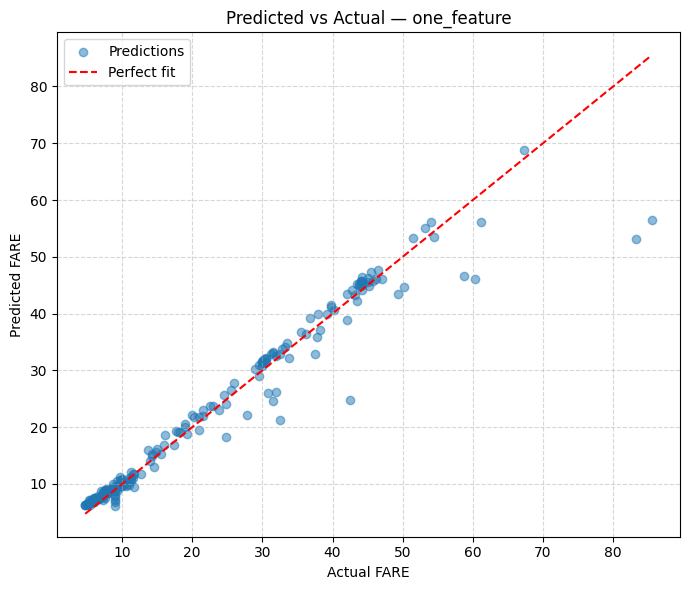

In [49]:
#Run Training and Plot Results
settings_1 = ModelSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=["TRIP_MILES"],
)

metrics = [keras.metrics.RootMeanSquaredError(name="rmse")]

model_1 = create_model(settings_1, metrics)
model_1.summary()

training_1 = train_model(
    model_name="one_feature",
    model=model_1,
    dataset=training_df,
    label_name="FARE",
    settings=settings_1,
)

plot_training_metrics(training_1, ["rmse"])
plot_predictions(training_1, training_df, "FARE")

Epoch 1/20


634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - loss: 619.1143 - rmse: 24.7071
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 42.7327 - rmse: 6.5061
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - loss: 20.9372 - rmse: 4.5749
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - loss: 15.6207 - rmse: 3.9471
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 12.0283 - rmse: 3.4591
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - loss: 12.4050 - rmse: 3.5191
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - loss: 11.9096 - rmse: 3.4442
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - loss: 11.3836 - rmse: 3.3633
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - loss: 13.4847 - rmse: 3.6615
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - loss: 11.7515 - rmse: 3.4233
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step - loss: 13.3774 - rmse: 3.6509
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - loss: 13.1208 - r

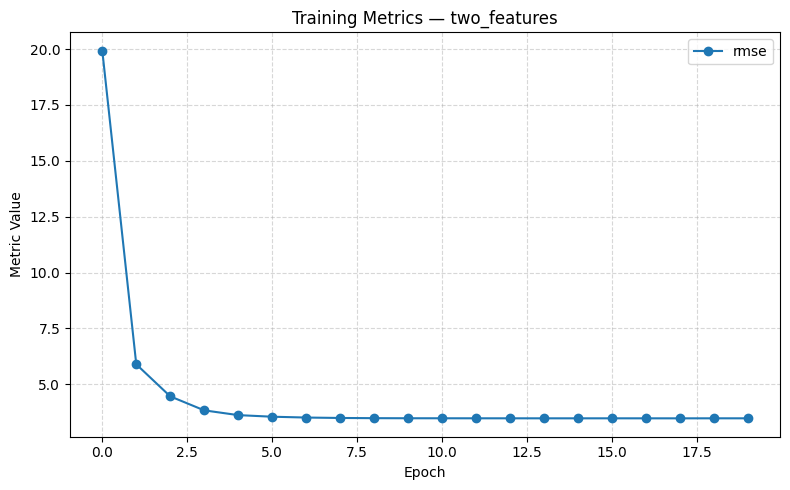

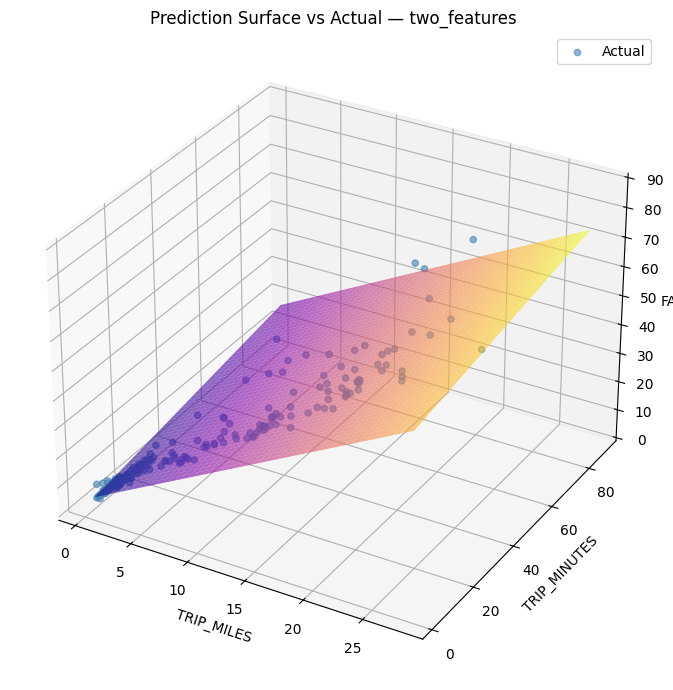

In [50]:
#Two Features
#Add derived feature for trip duration in minutes, since the original dataset only has trip duration in seconds, and minutes may be more interpretable and have a more linear relationship with fare.
training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS'] / 60

#Hyperparameters for the model
settings_2 = ModelSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=["TRIP_MILES", "TRIP_MINUTES"],
)

metrics = [keras.metrics.RootMeanSquaredError(name="rmse")] 

model_2 = create_model(settings_2, metrics)

training_2 = train_model("two_features", model_2, training_df, "FARE", settings_2)

plot_training_metrics(training_2, ["rmse"])
plot_predictions(training_2, training_df, "FARE")